In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import re
%matplotlib inline

In [7]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,Employee ID,Age,Gender,Months at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Marital Status,Number of Dependents,Job Level,Company Size,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,Married,0,Mid,Medium,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,Divorced,3,Mid,Medium,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,Married,3,Mid,Medium,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,Single,2,Mid,Small,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,Divorced,0,Senior,Medium,No,No,No,Fair,Medium,Stayed


In [46]:
train.describe()

,Employee ID,Age,Months at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,37227.118729,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075
std,21519.150028,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689
min,1.000000,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000
25%,18580.250000,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000
50%,37209.500000,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000
75%,55876.750000,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000


In [5]:
train_report = ProfileReport(train, title = "Employee Attrition Analysis")
train_report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 23/23 [00:01<00:00, 22.93it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [43]:
#Check for missing Values
missing = train.isnull().sum()
missing

Employee ID                 0
Age                         0
Gender                      0
Months at Company           0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64

In [41]:
#Detect Duplicates
duplicates = train[train.duplicated()]
duplicates

,Employee ID,Age,Gender,Months at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Marital Status,Number of Dependents,Job Level,Company Size,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition


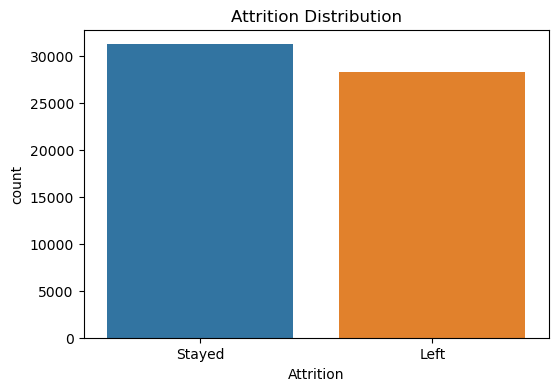

Attrition
Stayed    52.451425
Left      47.548575
Name: proportion, dtype: float64


In [6]:
# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=train, hue = 'Attrition')
plt.title("Attrition Distribution")
plt.show()
print(train['Attrition'].value_counts(normalize=True)*100)

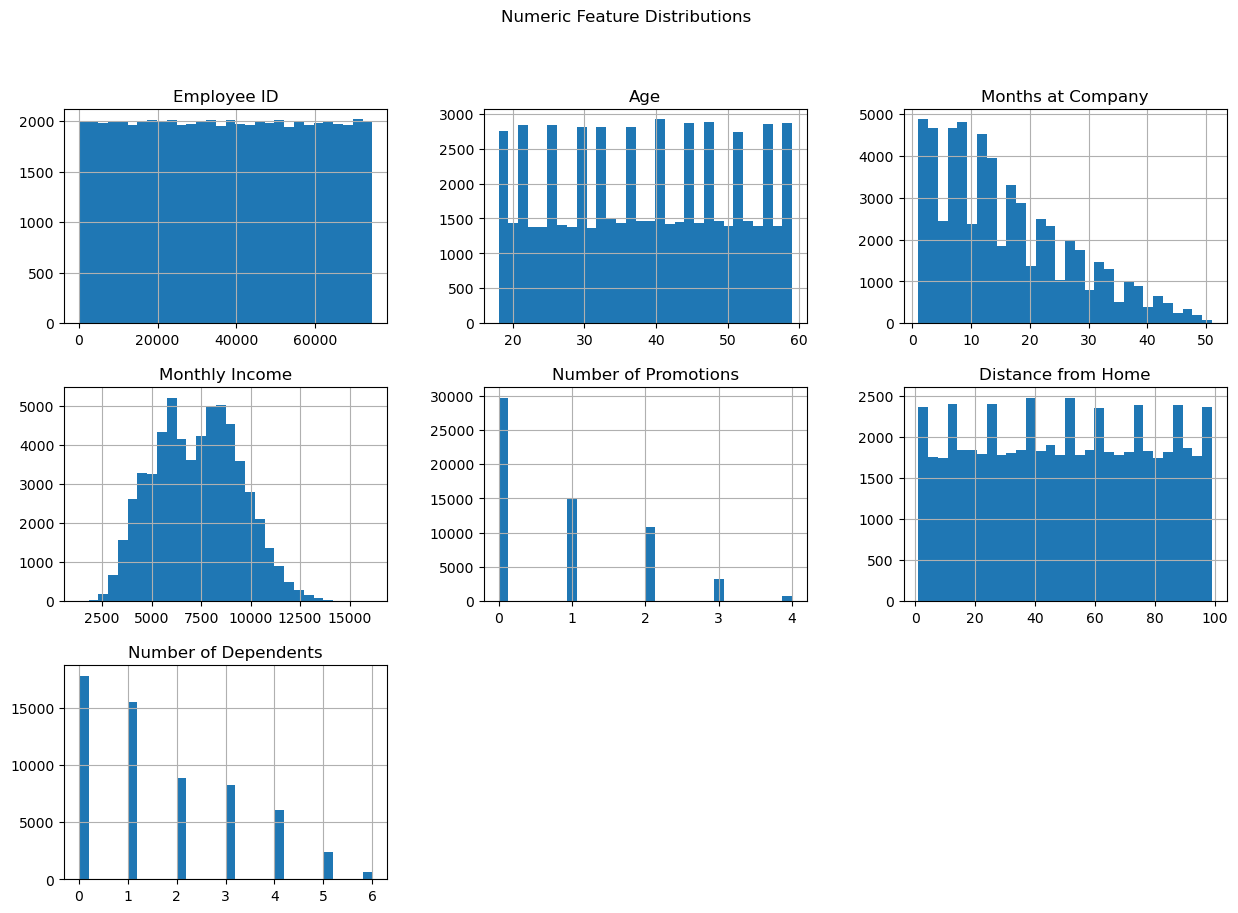

In [35]:
#Distribution Check
train[num_cols].hist(bins=30, figsize=(15,10))
plt.suptitle("Numeric Feature Distributions")
plt.show()

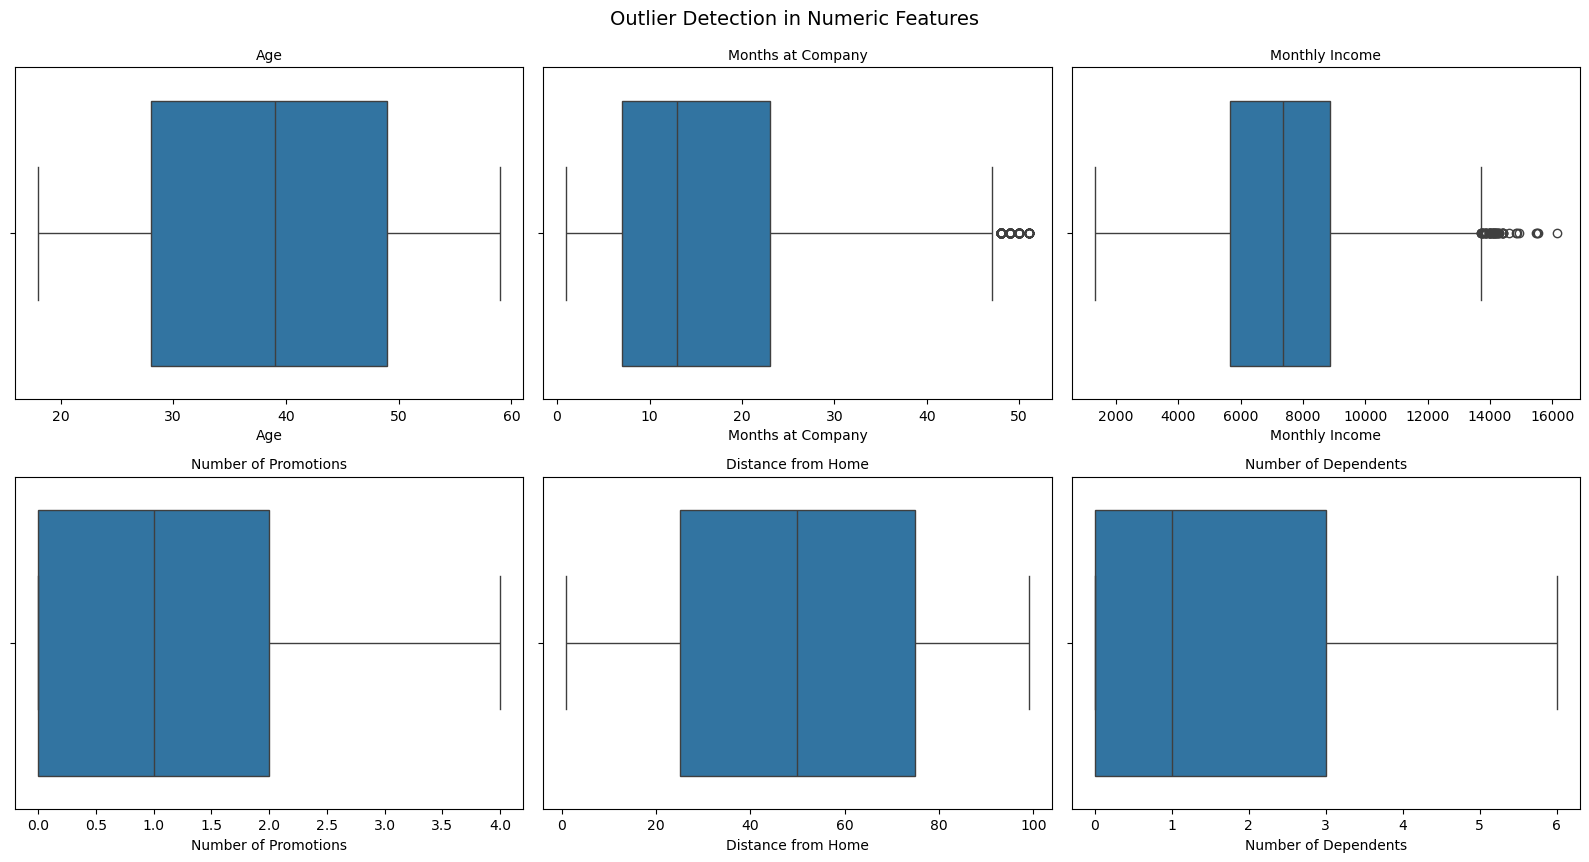

In [50]:
#Outlier Analysis
# Select numeric columns
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.drop('Employee ID')

plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=train[col])
    plt.title(f'{col}', fontsize=10)
    plt.tight_layout()
plt.suptitle("Outlier Detection in Numeric Features", fontsize=14, y=1.02)
plt.show()

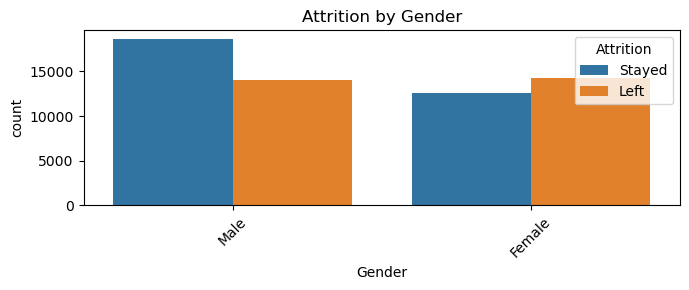

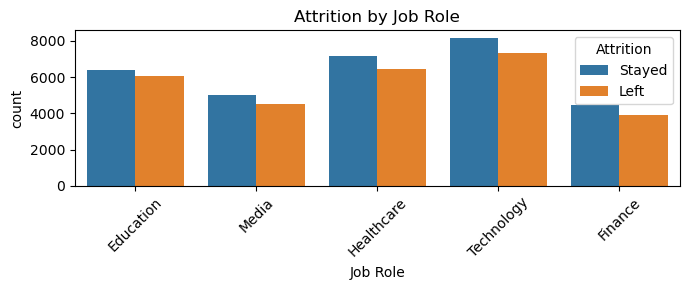

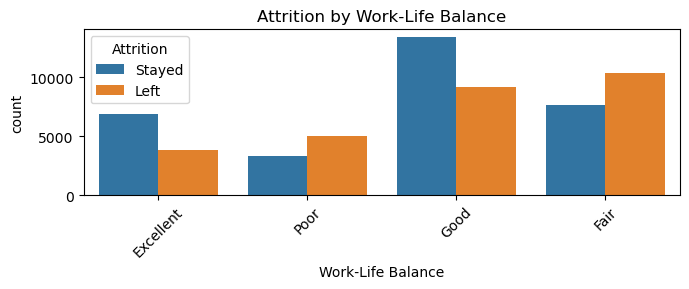

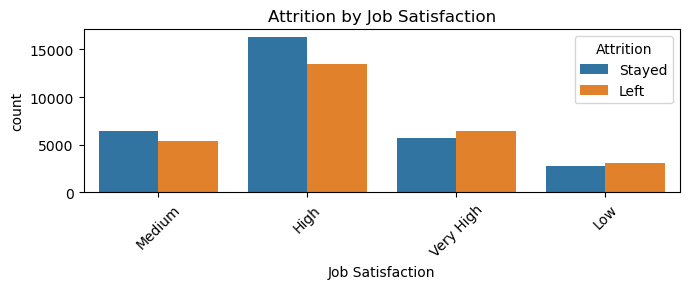

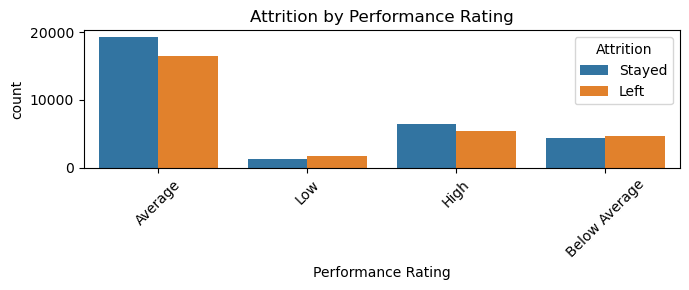

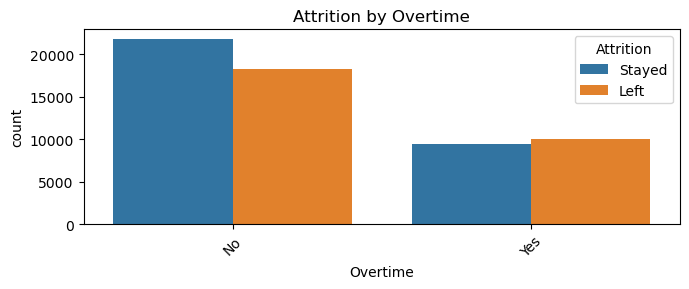

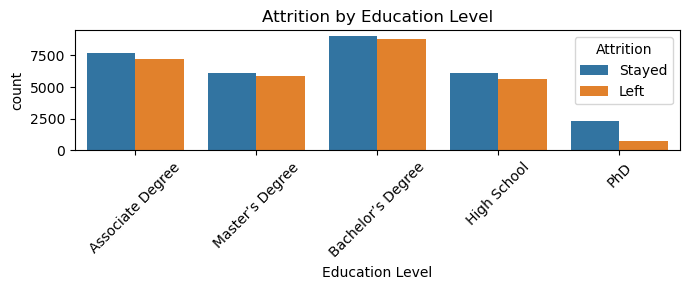

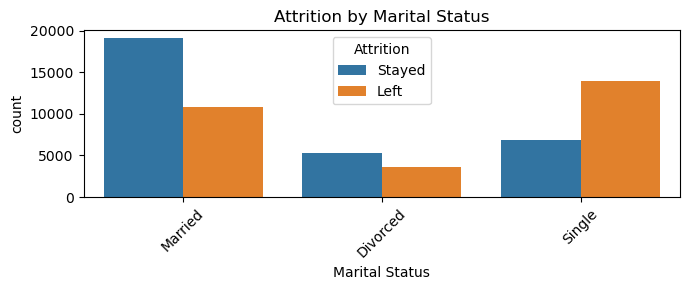

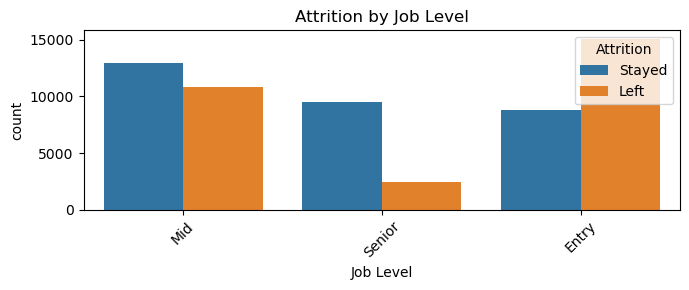

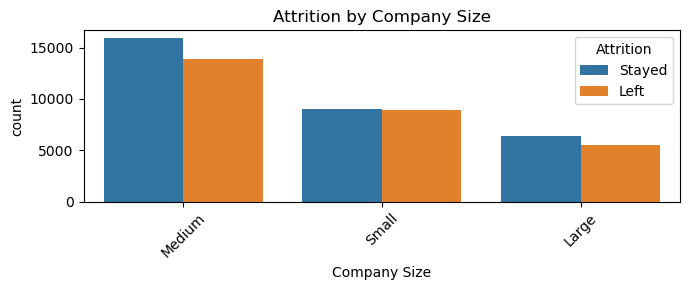

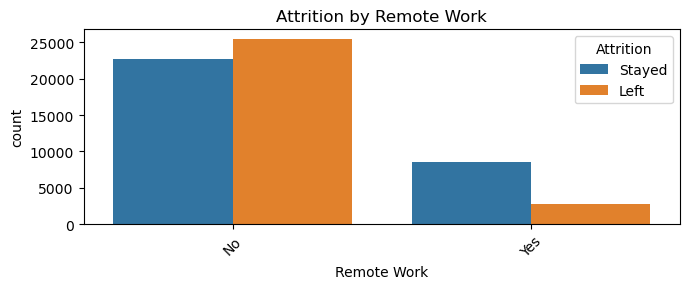

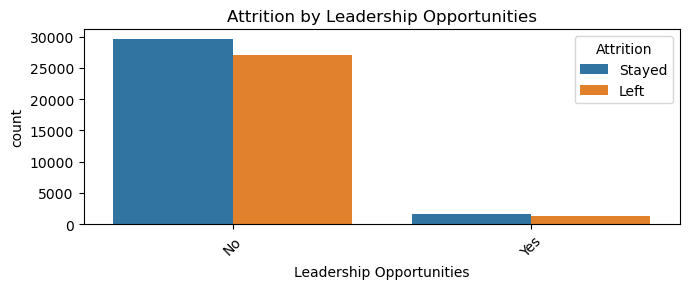

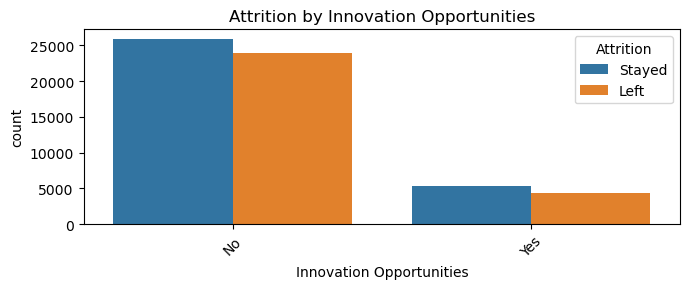

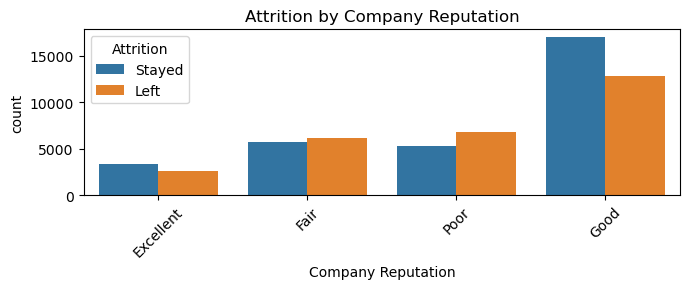

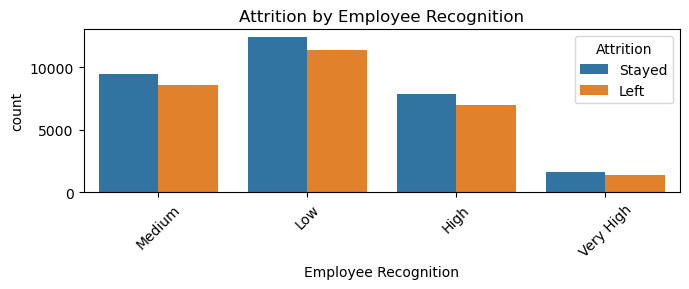

In [62]:
# Categorical vs Target Relationship
cat_cols = [c for c in train.columns if train[c].dtype == 'object' and c != 'Attrition']

for col in cat_cols:
    plt.figure(figsize=(7,3))
    sns.countplot(x=col, hue='Attrition', data=train)
    plt.title(f"Attrition by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

EDA Comments
- No Missing and Duplicate Values
- No significant outliers that need to drop
- Very high attrition rate means almost half of the personnel had left the company
- All Distributions seems normal, right-skewness on Months at Companys and Promotions, No of Dependents indicates younger, more single workforce who have less promotion progress in career. Ages distribution indicates various in age groups.
- Possible important features effecting target: Work-Life Balance, Employee Recognition, Remote Work, Job Level, Maritial Status, Overtime (from data), Monthly Income, Tenure, Age (from experience) might effect Attrition as well.

In [10]:
#3. Rename column to fit BigQuery syntax

def clean_bq_col(colname: str) -> str:
    col = str(colname).strip()

    # Replace all invalid characters with underscore
    col = re.sub(r'[^0-9a-zA-Z_]', '_', col)

    # If it starts with a digit, prefix with 'col_'
    if re.match(r'^[0-9]', col):
        col = 'col_' + col

    # Collapse multiple underscores
    col = re.sub(r'_+', '_', col)

    # Strip leading/trailing underscores (but not the 'col_' prefix)
    col = col.strip('_')

    # Convert to lowercase (BigQuery treats names case-insensitively)
    return col.lower()

# Apply cleaning to dataset
train.columns = [clean_bq_col(c) for c in train.columns]  # Train dataset
test.columns = [clean_bq_col(c) for c in test.columns]
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   employee_id               59598 non-null  int64 
 1   age                       59598 non-null  int64 
 2   gender                    59598 non-null  object
 3   months_at_company         59598 non-null  int64 
 4   job_role                  59598 non-null  object
 5   monthly_income            59598 non-null  int64 
 6   work_life_balance         59598 non-null  object
 7   job_satisfaction          59598 non-null  object
 8   performance_rating        59598 non-null  object
 9   number_of_promotions      59598 non-null  int64 
 10  overtime                  59598 non-null  object
 11  distance_from_home        59598 non-null  int64 
 12  education_level           59598 non-null  object
 13  marital_status            59598 non-null  object
 14  number_of_dependents  

In [12]:
#Export cleaned data
train.to_csv('train_cleaned.csv', index=False)
test.to_csv('test_cleaned.csv',index=False)